In [2]:
from rdkit import Chem
import csv
import pandas as pd
from urllib.request import urlopen
from urllib.parse import quote
import pubchempy as pcp
from math import nan
import numpy as np
from rdkit.Chem import AllChem, Descriptors
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import joblib
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [58]:
"""
The resulting unique acceptor and donor fragments were subjected to a selection procedure: 
Only organic fragments (atoms H, C, N, O, F, Cl, S, Br, I) were accepted. 
"""


"""
Transforme les fichiers .sdf de HBA et HBD en liste de SMILES et masse molaire du SMILES
"""
def extract_data_to_csv(sdf_path, filename):
    dataHB = []

    suppl = Chem.SDMolSupplier(sdf_path, sanitize=True)
    with open(filename, "w", newline="", encoding="utf-8") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["SMILES", "Masse_Molaire"])

        for mol in suppl:
            if mol is None:
                continue

            smiles = Chem.MolToSmiles(mol)

            if mol.HasProp("Molecular_Weight"):
                mw = mol.GetProp("Molecular_Weight")
            else:
                from rdkit.Chem import Descriptors
                mw = Descriptors.MolWt(mol)

            dataHB.append((smiles, mw))
            writer.writerow([smiles, mw])
        
    return dataHB


In [59]:
"""
Charge les 4 fichiers contenant les DES  
"""
df_Density = pd.read_csv('./DES_DATA/Density.csv')
df_Des = pd.read_csv('./DES_DATA/DES_init_update.csv')
df_Melting = pd.read_csv('./DES_DATA/Melting_temperature.csv')
df_Viscosity = pd.read_csv('./DES_DATA/Viscosity.csv')

In [68]:

"""
On supprime les colonnes qui ne nous interesse pas et on sauvegarde à part les références
On renvoie les dataframes propres 
"""
df_Density_copy = df_Density.copy()
allSources_Density = df_Density_copy["Reference (DOI)"]
df_Density_copy = df_Density_copy.drop(columns=["Number of components", "Type of DES", "Density, g/cm^3", "Temperature, K", "Reference (DOI)"])
df_Density_copy = df_Density_copy.drop_duplicates()
df_Density_copy = pd.DataFrame(df_Density_copy)

df_Viscosity_copy = df_Viscosity.copy()
allSources_Viscosity = df_Viscosity_copy["Reference (DOI)"]
df_Viscosity_copy = df_Viscosity_copy.drop(columns=["Number of components", "Type of DES", "Viscosity, cP", "Temperature, K", "Reference (DOI)"])
df_Viscosity_copy = df_Viscosity_copy.drop_duplicates()
df_Viscosity_copy = pd.DataFrame(df_Viscosity_copy)

df_Melting_copy = df_Melting.copy()
allSources_Melting = df_Melting_copy["Reference (DOI)"]
df_Melting_copy = df_Melting_copy.drop(columns=["Number of components", "Component#1", "Component#2", "Tmelt, K", "Phase diagram (Yes/No)", "Reference (DOI)"])
df_Melting_copy = df_Melting_copy.drop_duplicates()
df_Melting_copy = pd.DataFrame(df_Melting_copy)

df_Des_copy = df_Des.copy()
df_Des_copy = df_Des_copy.drop(columns=["Component#1", "inchi#1", "H#1", "Component#2", "inchi#2", "H#2", "T_EP", "PD"])
df_Des_copy = df_Des_copy.drop_duplicates()
df_Des_copy = pd.DataFrame(df_Des_copy)


In [ ]:
"""
Construction du fichier de sources 
On ajoute toute les sources dans une liste, on supprime les doublons et on sauvegarde cette liste dans un fichier 
"""
df_AllSources = []

df_AllSources.extend(allSources_Density)
df_AllSources.extend(allSources_Viscosity)
df_AllSources.extend(allSources_Melting)

df_AllSources = pd.DataFrame(df_AllSources)
df_AllSources = df_AllSources.drop_duplicates()

df_AllSources.to_csv("./results/df_AllSources.csv", index=False, encoding='utf-8')

In [ ]:
"""
Elimine les lignes contenant un troisième composants 
On fait ça car pas assez de données sur le troisième composant
"""
col_density_7 = df_Density_copy.columns[7]
df_Density_copy = df_Density_copy[df_Density_copy[col_density_7].isna()]

col_viscosity_9 = df_Viscosity.columns[9]
df_Viscosity = df_Viscosity[df_Viscosity[col_viscosity_9].isna()]

Component#3
Component#3


In [ ]:
"""
Les deux fonctions permettent de transformer les IUPAC en SMILES, exemple: hydrogen->[H] 
"""

def CIRconvert(ids):
    try:
        url = 'http://cactus.nci.nih.gov/chemical/structure/' + quote(ids) + '/smiles'
        ans = urlopen(url).read().decode('utf8')
        return ans
    except:
        return None
    
def IUPACconvertToSmiles(name):
    try:
        compound = pcp.get_compounds(name, "name")
        return compound.cid
    except:
        return None


**dans l'API et dans la librairie pour convertir les IUPAC en SMILES, certains IUPAC ne sont pas référencés, par conséquent avec le site pubchem, on récupère à la main les SMILES. (le nombre de non trouvé reste peu, la manipulation peut se faire à la main)**


- Aluminium Chloride Anhydrous                  
    * [Al+3].[Cl-].[Cl-].[Cl-]  
- Cuprymina                                     
    * [Cl-].[Cl-].[64Cu+2]  
- STANNIC CHLORIDE [MI]
    * [Cl-].[Cl-].[Cl-].[Cl-].[Sn+4]  
- N,N-Diethylethanolammonium chloride           
    * CC[N+](CC)(CC)CC1=CC=CC=C1.[Cl-]  
- N-octyl 4-hydroxybenzoate                     
    * CCCCCCCCOC(=O)C1=CC=C(C=C1)O  
- 1-Napthol                                     
    * C1=CC=C2C(=C1)C=CC=C2O  
- P-Toluene sulfonic acid                       
    * CC1=CC=C(C=C1)S(=O)(=O)O  
- Neodymium Nitrate, Nd(NO3)3                   
    * [N+](=O)(O)[O-].[Nd]  
- CuCl2
    * Cl[Cu]Cl
- n,n-Diethylethanolammonium chloride
    * CC[N+](CC)(CC)CC1=CC=CC=C1.[Cl-]
- Lithium bis(trifluoromethanesulphonyl)imide
    * [Li+].C(F)(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F
- ZrOCl2 
    * O=[Zr].Cl.Cl
- Guanidinecarbonate
    * C(=N)(N)N.C(=N)(N)N.C(=O)(O)O


In [ ]:
dictionaryComponentToSmiles = {}
listError = []


"""
On ajoute ici les IUPAC/SMILES manquant non référencé en utilisant les fonctions CIRconvert et IUPACconvertToSmiles
"""
# Density
dictionaryComponentToSmiles["Aluminium Chloride Anhydrous"] = "[Al+3].[Cl-].[Cl-].[Cl-]"
dictionaryComponentToSmiles["Cuprymina"] = "[Cl-].[Cl-].[64Cu+2]"
dictionaryComponentToSmiles["STANNIC CHLORIDE [MI]"] = "[Cl-].[Cl-].[Cl-].[Cl-].[Sn+4]"
dictionaryComponentToSmiles["N,N-Diethylethanolammonium chloride"] = "CC[N+](CC)(CC)CC1=CC=CC=C1.[Cl-]"
dictionaryComponentToSmiles["N-octyl 4-hydroxybenzoate"] = "CCCCCCCCOC(=O)C1=CC=C(C=C1)O"
dictionaryComponentToSmiles["1-Napthol"] = "C1=CC=C2C(=C1)C=CC=C2O"
dictionaryComponentToSmiles["P-Toluene sulfonic acid"] = "CC1=CC=C(C=C1)S(=O)(=O)O"
dictionaryComponentToSmiles["Neodymium Nitrate, Nd(NO3)3"] = "[N+](=O)(O)[O-].[Nd]"

# Viscosity
dictionaryComponentToSmiles["CuCl2"] = "Cl[Cu]Cl"
dictionaryComponentToSmiles["n,n-Diethylethanolammonium chloride"] = "CC[N+](CC)(CC)CC1=CC=CC=C1.[Cl-]"
dictionaryComponentToSmiles["Lithium bis(trifluoromethanesulphonyl)imide"] = "[Li+].C(F)(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F"
dictionaryComponentToSmiles["ZrOCl2"] = "O=[Zr].Cl.Cl"
dictionaryComponentToSmiles["Guanidinecarbonate"] = "C(=N)(N)N.C(=N)(N)N.C(=O)(O)O"
dictionaryComponentToSmiles["Cobalt chloride (cocl2)"] = "[Cl-].[Cl-].[Co+2]"


"""
Cette fonction permet de transformer les colonnes actuellement en IUPAC en SMILES 
Pour chaque ligne, pour chaque composant de la ligne,
    On regarde si le IUPAC est dans le dictionnaire (à la base contenant les lignes juste au dessus puis les résultats stockés)
    Si ce n'est pas le cas, on regarde avec la fonction IUPACconvertToSmiles 
    Si ce n'est pas le cas, on regarde avec la fonction CIRconvert (prend plus de temps car fait des appel API)
on retourne le dataframe nettoyé et le dictionnaire IUPAC to SMILES pour le réutiliser afin de gagner du temps 

temps d'execution sur ma machine: ~7min
"""
def transformDf(dataframe, dictionaryComponentToSmiles, listError):
    for index, row in dataframe.iterrows():
        components = [
            {"col": "Component#1", "data": row["Component#1"]},
            {"col": "Component#2", "data": row["Component#2"]},
            {"col": "Component#3", "data": row["Component#3"]},
        ]

        for component in components:
            if (component["data"] and pd.notna(component["data"]) and component["data"] != 0):

                nom_chimique = component["data"]
                nom_colonne = component["col"]

                if nom_chimique not in dictionaryComponentToSmiles:
                    resSmiles = IUPACconvertToSmiles(nom_chimique)
                    if(resSmiles == None):
                        resSmiles = CIRconvert(nom_chimique)
                    if(resSmiles == None):
                        if(nom_chimique not in listError):
                            listError.append(nom_chimique)
                            print(f"ERROR: {nom_chimique}")
                    else :
                        dictionaryComponentToSmiles[nom_chimique] = resSmiles
                        dataframe.at[index, nom_colonne] = resSmiles
                else:
                    dataframe.at[index, nom_colonne] = (dictionaryComponentToSmiles[nom_chimique])
    return dataframe, dictionaryComponentToSmiles, listError

df_Density_copy, dictionaryComponentToSmiles, listError = transformDf(df_Density_copy, dictionaryComponentToSmiles, listError)
df_Viscosity_copy, dictionaryComponentToSmiles, listError = transformDf(df_Viscosity_copy, dictionaryComponentToSmiles, listError)

In [ ]:
""" 
Permet de standardiser les TypesDES pour qu'ils soient: "IL, I, II, ..."
"""
dictTransformTypeDES = {
    "IL mixture" : "IL",
    "Type I" : "I",
    "Type II" : "II",
    "Type III" : "III",
    "Type IV" : "IV",
    "Type V" : "V" 
}

df_Des_copy["Type"] = (
    df_Des_copy["Type"].map(dictTransformTypeDES).fillna(df_Des_copy["Type"])
)

"""
Créer une nouvelle colonne X#2 donnant le ratio du composant 2 étant: 1 - X#1 
car Des_copy ne possède que le ratio X#1 (composant 1) 
"""
tabX2data = []
for i in df_Des_copy.values:
    tabX2data.append(1 - i[4])

df_Des_copy["X#2"] = tabX2data

In [ ]:
"""
Converti la colonne Type de DES en plusieurs listes où une catégorie de la colonne type de DES deviens une colonne à part entière
C'est ce que l'on appelle du OneHotEncoding
"""
def returnOneHotEncod(type):
    if(type == "I" or type == 1 or type == "1"):   return [0,1,0,0,0,0]
    if(type == "II" or type == 2 or type == "2"):  return [0,0,1,0,0,0]
    if(type == "III" or type == 3 or type == "3"): return [0,0,0,1,0,0]
    if(type == "IV" or type == 4 or type == "4"):  return [0,0,0,0,1,0]
    if(type == "V" or type == 5 or type == "5"):   return [0,0,0,0,0,1]
    return [1,0,0,0,0,0]


""" 
Réunit les 4 fichiers de DES en un seul
Parcours les 4 fichiers et le ajoute à dataGlobal

Créer un dataframe final
"""
dataGlobal = {
    'TypeIL': [],
    'TypeI': [],
    'TypeII': [],
    'TypeIII': [],
    'TypeIV': [],
    'TypeV': [],
    'Smile#1': [],
    'Smile#2': [],
    #'Smile#3': [],
    'X#1': [],
    'X#2': [],
    #'X#3': []
}

keepIL = False

for i in df_Density_copy.values:
    dataGlobal['TypeIL'].append(0)
    dataGlobal['TypeI'].append(i[0])
    dataGlobal['TypeII'].append(i[1])
    dataGlobal['TypeIII'].append(i[2])
    dataGlobal['TypeIV'].append(i[3])
    dataGlobal['TypeV'].append(i[4])
    dataGlobal['Smile#1'].append(i[5])
    dataGlobal['Smile#2'].append(i[6])
    #dataGlobal['Smile#3'].append(i[7])
    dataGlobal['X#1'].append(i[8])
    dataGlobal['X#2'].append(i[9])
    #dataGlobal['X#3'].append(i[10])

for i in df_Viscosity_copy.values:
    dataGlobal['TypeIL'].append(0)
    dataGlobal['TypeI'].append(i[0])
    dataGlobal['TypeII'].append(i[1])
    dataGlobal['TypeIII'].append(i[2])
    dataGlobal['TypeIV'].append(i[3])
    dataGlobal['TypeV'].append(i[4])
    dataGlobal['Smile#1'].append(i[5])
    dataGlobal['Smile#2'].append(i[6])
    #dataGlobal['Smile#3'].append(i[7])
    dataGlobal['X#1'].append(i[8])
    dataGlobal['X#2'].append(i[9])
    #dataGlobal['X#3'].append(i[10])

for i in df_Melting_copy.values:
    tabType = returnOneHotEncod(i[0])

    if(keepIL == True):
        dataGlobal['TypeIL'].append(tabType[0])
        dataGlobal['TypeI'].append(tabType[1])
        dataGlobal['TypeII'].append(tabType[2])
        dataGlobal['TypeIII'].append(tabType[3])
        dataGlobal['TypeIV'].append(tabType[4])
        dataGlobal['TypeV'].append(tabType[5])
        dataGlobal['Smile#1'].append(i[3])
        dataGlobal['Smile#2'].append(i[5])
        #dataGlobal['Smile#3'].append(nan)
        dataGlobal['X#1'].append(i[1])
        dataGlobal['X#2'].append(i[2])
        #dataGlobal['X#3'].append(0)
    elif keepIL == False and tabType[0] != 1:
        dataGlobal['TypeIL'].append(0)
        dataGlobal['TypeI'].append(tabType[1])
        dataGlobal['TypeII'].append(tabType[2])
        dataGlobal['TypeIII'].append(tabType[3])
        dataGlobal['TypeIV'].append(tabType[4])
        dataGlobal['TypeV'].append(tabType[5])
        dataGlobal['Smile#1'].append(i[3])
        dataGlobal['Smile#2'].append(i[5])
        #dataGlobal['Smile#3'].append(nan)
        dataGlobal['X#1'].append(i[1])
        dataGlobal['X#2'].append(i[2])
        #dataGlobal['X#3'].append(0)
    

for i in df_Des_copy.values:
    tabType = returnOneHotEncod(i[3])
    if(keepIL == True):
        dataGlobal['TypeIL'].append(tabType[0])
        dataGlobal['TypeI'].append(tabType[1])
        dataGlobal['TypeII'].append(tabType[2])
        dataGlobal['TypeIII'].append(tabType[3])
        dataGlobal['TypeIV'].append(tabType[4])
        dataGlobal['TypeV'].append(tabType[5])
        dataGlobal['Smile#1'].append(i[0])
        dataGlobal['Smile#2'].append(i[2])
        #dataGlobal['Smile#3'].append(nan)
        dataGlobal['X#1'].append(i[4])
        dataGlobal['X#2'].append(i[6])
        #dataGlobal['X#3'].append(0)
    elif keepIL == False and tabType[0] != 1:
        dataGlobal['TypeIL'].append(0)
        dataGlobal['TypeI'].append(tabType[1])
        dataGlobal['TypeII'].append(tabType[2])
        dataGlobal['TypeIII'].append(tabType[3])
        dataGlobal['TypeIV'].append(tabType[4])
        dataGlobal['TypeV'].append(tabType[5])
        dataGlobal['Smile#1'].append(i[0])
        dataGlobal['Smile#2'].append(i[2])
        #dataGlobal['Smile#3'].append(nan)
        dataGlobal['X#1'].append(i[4])
        dataGlobal['X#2'].append(i[6])
        #dataGlobal['X#3'].append(0)
    
"""
for idx, value in enumerate(dataGlobal['X#3']):
    if pd.isna(value):
        dataGlobal['X#3'][idx] = 0

for idx, value in enumerate(dataGlobal['Smile#3']):
    if pd.isna(value):
        dataGlobal['Smile#3'][idx] = 0
"""
df_dataGlobal = pd.DataFrame(dataGlobal)

In [ ]:
"""
Supprime les doublons qui peuvent exister apres le regroupement des 4 fichiers
"""
df_dataGlobal = df_dataGlobal.drop_duplicates()
df_dataGlobal = pd.DataFrame(df_dataGlobal)

In [ ]:
""" 
Pour un SMILES donné, retourne une liste de descripteur de ce dernier sous forme de tableau
"""
def getMolDescriptors(smi):
    mol = Chem.MolFromSmiles(smi)
    return [fn(mol) for nm, fn in Descriptors._descList]

""" 
Pour un SMILES donné, retourne un code unique sous forme de tableau avec des valeurs entre 0 et 1
"""
def smiles_to_MACCS(smi):
    mol = Chem.MolFromSmiles(smi)
    return np.array(AllChem.GetMACCSKeysFingerprint(mol), float)

"""  
Pour un SMILES, retourne le résultat des deux fonctions ci-dessus
"""
def getDescriptors(smi):
    if(smi != 0): return [getMolDescriptors(smi), smiles_to_MACCS(smi)]
    else: return [[0],[0]] 

In [ ]:
"""
Vérifie que les SMILES sont bien valide et que donc on peut en tirer des descripteurs/maccs
"""
def is_valid_smiles(smiles):
    if pd.isna(smiles) or smiles == "" or smiles == 0:
        return True

    mol = Chem.MolFromSmiles(str(smiles))
    return mol is not None

masque_valide = df_dataGlobal.apply(lambda row: is_valid_smiles(row["Smile#1"]) and is_valid_smiles(row["Smile#2"]), axis=1)
df_dataGlobal = df_dataGlobal[masque_valide].copy()

In [ ]:
"""
Force le composant avec le MOINS de donneurs de liaisons H à être le Composant 1 (HBA).
Inverse également le ratio molaire X#1 et X#2 si un changement de position a lieu.
"""
def reordonner_hba_hbd_et_ratios(row):
    smi1, smi2 = str(row['Smile#1']), str(row['Smile#2'])
    x1, x2 = row['X#1'], row['X#2']
    
    mol1 = Chem.MolFromSmiles(smi1)
    mol2 = Chem.MolFromSmiles(smi2)
    
    if mol1 is None or mol2 is None:
        return smi1, smi2, x1, x2
        
    h_donors_1 = Descriptors.NumHDonors(mol1)
    h_donors_2 = Descriptors.NumHDonors(mol2)
    
    if h_donors_1 > h_donors_2:
        return smi2, smi1, x2, x1  
    
    return smi1, smi2, x1, x2

df_dataGlobal[['Smile#1', 'Smile#2', 'X#1', 'X#2']] = df_dataGlobal.apply(
    lambda r: pd.Series(reordonner_hba_hbd_et_ratios(r)), axis=1
)

In [ ]:
molDes1 = []
maccs1 = []
molDes2 = []
maccs2 = []
#molDes3 = []
#maccs3 = []


"""
Ajoute les colonnes descripteur et maccs au dataframe global
"""
for i in df_dataGlobal.values:
    descComp1 = getDescriptors(i[6])
    molDes1.append(descComp1[0])
    maccs1.append(descComp1[1])

    descComp2 = getDescriptors(i[7])
    molDes2.append(descComp2[0])
    maccs2.append(descComp2[1])

    #descComp3 = getDescriptors(i[8])
    #molDes3.append(descComp3[0])
    #maccs3.append(descComp3[1])

df_dataGlobal["des#1"] = molDes1
df_dataGlobal["des#2"] = molDes2
#df_dataGlobal["des#3"] = molDes3
df_dataGlobal["fp#1"] = maccs1
df_dataGlobal["fp#2"] = maccs2
#df_dataGlobal["fp#3"] = maccs3


In [ ]:
"""
copie le dataframe pour gagner du temps par la suite
"""
df_dataGlobal_copy = df_dataGlobal.copy()

In [ ]:
#df_dataGlobal = df_dataGlobal.drop(columns=["Smile#1", "Smile#2", "Smile#3"])

""" 
Supprime les colonnes SMILES devenu inutile car il y a maintenant les descripteurs/maccs
"""
df_dataGlobal_copy = df_dataGlobal_copy.drop(columns=["Smile#1", "Smile#2"])

In [ ]:
""" 
Récupère tout les descripteurs sous forme d'un tableau
Applique une standardisation sur le tableau pour avoir une moyenne de 0 et un écartype de 1
Transforme les valeurs nan en 0 
"""
X_des1 = np.array(df_dataGlobal_copy["des#1"].tolist())
X_des2 = np.array(df_dataGlobal_copy["des#2"].tolist())

toutes_les_molecules = np.vstack((X_des1, X_des2))
scaler = StandardScaler()
scaler.fit(toutes_les_molecules)

X_des1_scaled = scaler.transform(X_des1)
X_des2_scaled = scaler.transform(X_des2)

X_des1_scaled = np.nan_to_num(X_des1_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_des2_scaled = np.nan_to_num(X_des2_scaled, nan=0.0, posinf=0.0, neginf=0.0)


"""
Créer N colonnes pour N elements dans le tableau puis insère les données dans les colonnes stockés dans df_des1_rdkit et df_des2_rdkit
(OneHotEncoding)
"""
num_des_features = X_des1_scaled.shape[1]
cols_des1_rdkit = [f"des1_RDKit_{i}" for i in range(num_des_features)]
cols_des2_rdkit = [f"des2_RDKit_{i}" for i in range(num_des_features)]

df_des1_rdkit = pd.DataFrame(X_des1_scaled, columns=cols_des1_rdkit, index=df_dataGlobal_copy.index)
df_des2_rdkit = pd.DataFrame(X_des2_scaled, columns=cols_des2_rdkit, index=df_dataGlobal_copy.index)


"""
La même chose qu'au-dessus mais pour maccs 
"""
X_maccs1 = np.array(df_dataGlobal_copy["fp#1"].tolist())
X_maccs2 = np.array(df_dataGlobal_copy["fp#2"].tolist())

num_maccs_features = X_maccs1.shape[1]  
cols_des1_maccs = [f"des1_MACCS_{i}" for i in range(num_maccs_features)]
cols_des2_maccs = [f"des2_MACCS_{i}" for i in range(num_maccs_features)]

df_des1_maccs = pd.DataFrame(X_maccs1, columns=cols_des1_maccs, index=df_dataGlobal_copy.index)
df_des2_maccs = pd.DataFrame(X_maccs2, columns=cols_des2_maccs, index=df_dataGlobal_copy.index)


""" Retire les colonnes du dataframe sur lesquels nous venons de travailler """
df_dataGlobal_copy = df_dataGlobal_copy.drop(columns=["des#1", "des#2", "fp#1", "fp#2"], errors="ignore")

""" Ajoute les nouvelles colonnes calculés avec le dataframe de base """
df_Final_IA = pd.concat(
    [
        df_dataGlobal_copy,
        df_des1_rdkit,
        df_des2_rdkit,
        df_des1_maccs,
        df_des2_maccs,
    ],
    axis=1,
)

""" Sauvegarde la standadisation appliqué afin de la réutiliser lorsque l'on devra prédire """
joblib.dump(scaler, './saveModel/scaler.pkl')


['scaler.pkl']

In [ ]:
"""
Sauvegarde le dataframe final d'entrainement
"""
df_Final_IA.to_csv("./results/df_Final_IA.csv", index=False, encoding='utf-8')

In [ ]:
""" 
Entrainement de l'IsolationForest
On construit les données d'entrainement, on paramètre le modele puis on l'entraine
On sauvegarde le modele
"""
features_cols = df_Final_IA.columns
X_train = df_Final_IA[features_cols].values

print(f"Structure de la matrice d'entraînement : {X_train.shape}")
print(f"Nombre de descripteurs analysés par l'IA : {len(features_cols)}")


model_iforest = IsolationForest(
    n_estimators=500,      # Nombre d'arbres à construire (plus il y a, plus c'est stable)
    contamination=0.05,    # Seuil de tolérance aux valeurs extrêmes
    max_features=1.0,      # Utilise toutes les colonnes pour construire les arbres
    random_state=42,       # Pour bloquer l'aléa et avoir les mêmes résultats à chaque fois
    n_jobs=-1              # Utilise tous les cœurs de votre processeur
)

model_iforest.fit(X_train)

joblib.dump(model_iforest, './saveModel/isolation_forest_des.pkl')

Structure de la matrice d'entraînement : (3161, 776)
Nombre de descripteurs analysés par l'IA : 776


['isolation_forest_des.pkl']

In [ ]:
"""
Affiche le point de bascule du score
Si le score prédit est sous la valeur donné, il y a des chance que ce soit un DES
Si le score prédit est au-dessus, il y a des chances que ce ne soit pas un DES 
"""
scores_train = model_iforest.score_samples(X_train)
predictions_train = model_iforest.predict(X_train)
seuil_exact = abs(scores_train[predictions_train == 1].min())

print(f"-> score en dessous de {seuil_exact:.4f} = Vrai DES")
print(f"-> score au-dessus de {seuil_exact:.4f} = Hors-zone")

Le vrai seuil mathématique de votre IA est : 0.5093
-> Un score en dessous de 0.5093 = Vrai DES
-> Un score au-dessus de 0.5093 = Rejeté / Hors-zone


c:\Users\marct\miniconda3\envs\desenv\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


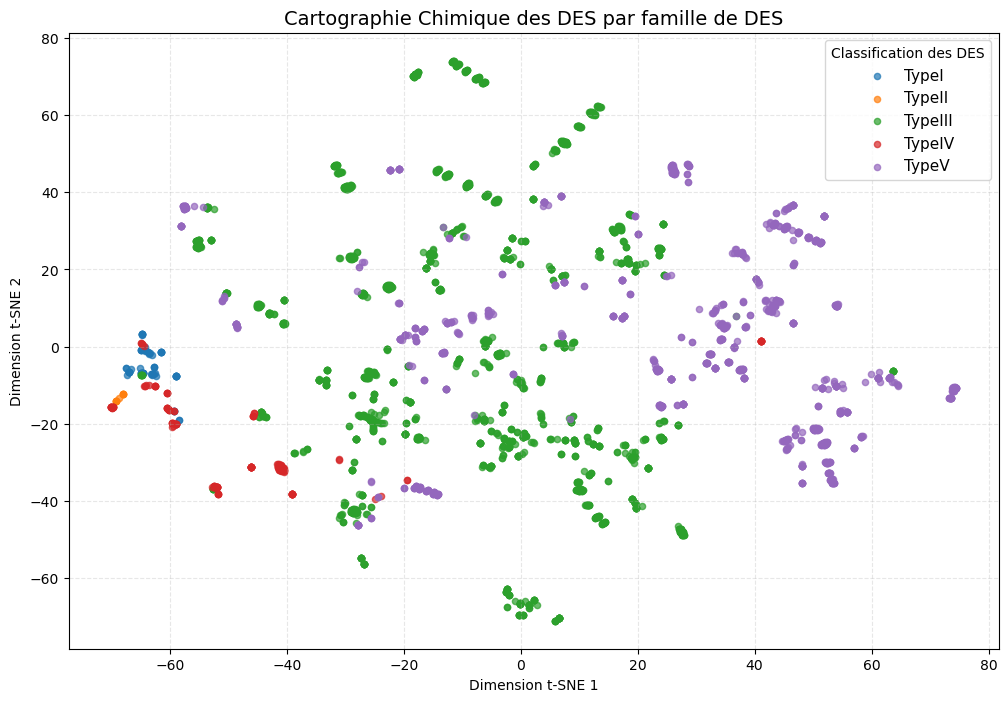

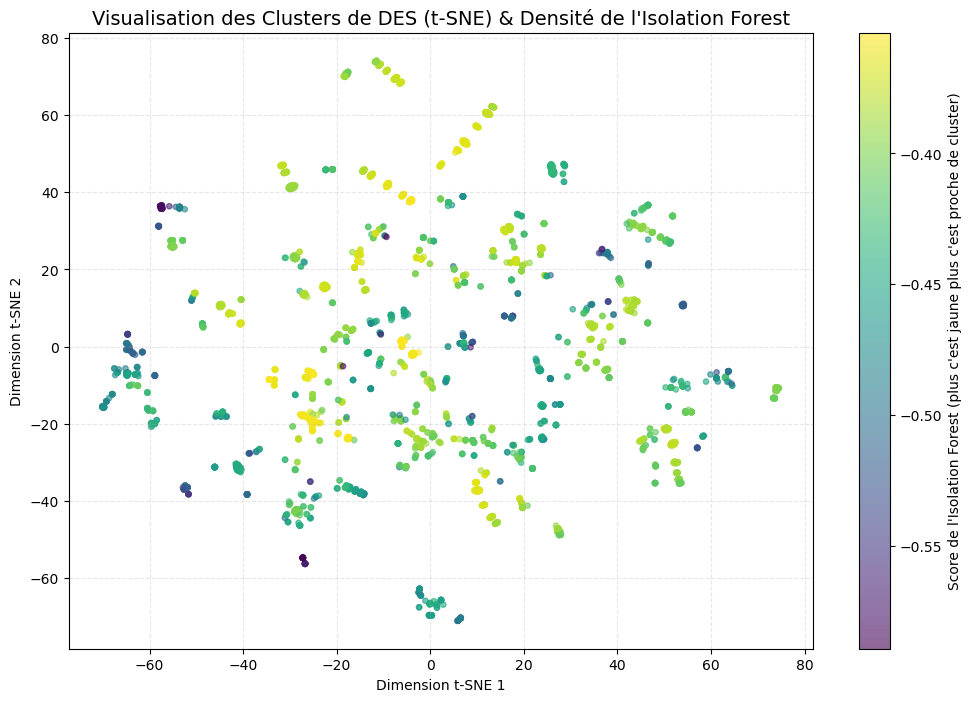

In [ ]:
"""
Permet de créer une vue graphique (vue déformée cela donne une idée)
"""
scores = model_iforest.score_samples(X_train)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
X_embedded = tsne.fit_transform(X_train)

"""
Affiche la répartition graphique par type de DES
""" 
def showPerTypeDes(X_embedded):
    colonnes_types = ["TypeIL", "TypeI", "TypeII", "TypeIII", "TypeIV", "TypeV"]
    type_reconstruit = df_Final_IA[colonnes_types].idxmax(axis=1)
    types_uniques = [t for t in colonnes_types if t in type_reconstruit.unique()]

    couleurs = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    couleur_map = {
        type_des: couleurs[i % len(couleurs)]
        for i, type_des in enumerate(types_uniques)
    }

    plt.figure(figsize=(12, 8))

    for type_des in types_uniques:
        indices = type_reconstruit == type_des

        plt.scatter(
            X_embedded[indices, 0], 
            X_embedded[indices, 1],
            c=couleur_map[type_des],
            label=type_des,
            alpha=0.7,
            s=20,
        )

    plt.title("Cartographie Chimique des DES par famille de DES", fontsize=14)

    plt.xlabel("Dimension t-SNE 1")
    plt.ylabel("Dimension t-SNE 2")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend(title="Classification des DES", loc="best", fontsize=11)
    plt.show()

"""
Affiche le graphique par avec en code couleur le résultat de l'isolationForest
""" 
def showPerConfiance(X_embedded):
    plt.figure(figsize=(12, 8))

    scatter = plt.scatter(
        X_embedded[:, 0],
        X_embedded[:, 1],
        c=scores,
        cmap="viridis", 
        alpha=0.6,
        s=15,
    )

    plt.colorbar(scatter, label="Score de l'Isolation Forest (plus c'est jaune plus c'est proche de cluster)")
    plt.title("Visualisation des Clusters de DES (t-SNE) & Densité de l'Isolation Forest", fontsize=14)
    plt.xlabel("Dimension t-SNE 1")
    plt.ylabel("Dimension t-SNE 2")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()


showPerTypeDes(X_embedded)
showPerConfiance(X_embedded)

In [ ]:
"""
Entraine l'autre modèle KNN (K Nearest Neighbors)
On utilise ce modèle pour pouvoir à partir d'un point retenu pas l'isolationForest, 
regarder si les 3 plus proches voisins sont proches les uns des autres (les 3 points appartiennent au même cluster)
et si les 3 plus proches voisins sont proches de ce point (appartient à ce cluster)
"""
knn_flash = NearestNeighbors(n_neighbors=3)
knn_flash.fit(X_train)
joblib.dump(knn_flash, './saveModel/knn.pkl')

['knn.pkl']